In [ ]:
'''
Because of the sheer size of the datasets, the script was only allowed to 
run for enough time to populate the "fake" and "real" folders in the train dataset with approx. 300-500 MB of images each.
'''

import os
from tqdm import tqdm
from datasets import load_dataset
from modelscope.msdatasets import MsDataset


def download_split_openfake(split_name, base_dir):
    print(f"\n Downloading OpenFake '{split_name}' split images")
    dataset = load_dataset("ComplexDataLab/OpenFake", split=split_name, streaming=True)

    # Output folders
    real_dir = os.path.join(base_dir, split_name, "real")
    fake_dir = os.path.join(base_dir, split_name, "fake")
    os.makedirs(real_dir, exist_ok=True)
    os.makedirs(fake_dir, exist_ok=True)

    for i, sample in enumerate(tqdm(dataset, desc=f"Processing {split_name} split")):
        image = sample["image"]
        label = sample["label"]  # 'real' or 'fake'

        # Convert any non-RGB image to RGB
        if image.mode != "RGB":
            image = image.convert("RGB")

        # Choose path based on real or fake
        subdir = real_dir if label == "real" else fake_dir
        image_path = os.path.join(subdir, f"{split_name}_{i:07d}.jpg")

        image.save(image_path)

    print(f"Finished {split_name} split: saved to {os.path.join(base_dir, split_name)}")


def import_openfake():
    base_dir="datasets/OpenFake"

    paths = [
            os.path.join(base_dir, "train", "real"),
            os.path.join(base_dir, "train", "fake"),
            os.path.join(base_dir, "test", "real"),
            os.path.join(base_dir, "test", "fake"),
        ]

    for path in paths:
        os.makedirs(path, exist_ok=True)

    download_split_openfake("train", base_dir)
    download_split_openfake("test", base_dir)

    print("\n Done. Dataset organized in:")
    print(os.path.abspath(base_dir))

def download_split_wildfake(split_name, base_dir):
    print(f"\n Downloading Wildfake '{split_name}' split images")
    dataset = MsDataset.load('hy2628982280/WildFake', subset_name='default', split=split_name)

    # Output folders
    real_dir = os.path.join(base_dir, split_name, "real")
    fake_dir = os.path.join(base_dir, split_name, "fake")
    os.makedirs(real_dir, exist_ok=True)
    os.makedirs(fake_dir, exist_ok=True)

    for i, sample in enumerate(tqdm(dataset, desc=f"Processing {split_name} split")):
        image = sample["image"]
        label = sample["IsFake"]  # 0 = real, 1 = fake (based on dataset card)


        # Convert RGBA to RGB to avoid JPEG errors
        if image.mode == "RGBA":
            image = image.convert("RGB")

        # Choose path based on real or fake
        subdir = real_dir if label == 0 else fake_dir
        image_path = os.path.join(subdir, f"{split_name}_{i:07d}.jpg")

        image.save(image_path)

    print(f"Finished {split_name} split: saved to {os.path.join(base_dir, split_name)}")

def import_wildfake():
    base_dir="datasets/WildFake"

    paths = [
            os.path.join(base_dir, "train", "real"),
            os.path.join(base_dir, "train", "fake"),
            os.path.join(base_dir, "test", "real"),
            os.path.join(base_dir, "test", "fake"),
        ]

    for path in paths:
        os.makedirs(path, exist_ok=True)

    download_split_wildfake('train', base_dir)
    download_split_wildfake('test', base_dir)
    print("\nDone. Dataset organized in:")
    print(os.path.abspath(base_dir))

def download_split_dragon(dataset_split, split_name, out_dir):
    os.makedirs(out_dir, exist_ok=True)

    for i, sample in enumerate(tqdm(dataset_split, desc=f"Processing {split_name}")):

        # Images are stored under png
        image = sample["png"]
        if image.mode == "RGBA":
            image = image.convert("RGB")

        filename = f"{split_name}_{i:07d}.jpg"
        image.save(os.path.join(out_dir, filename))

def import_dragon():
    base_dir = 'datasets/DRAGON'
    size_split = "ExtraLarge"
    print(f"Downloading DRAGON ({size_split}) subset")
    ds = load_dataset("lesc-unifi/dragon", size_split)

    # Create output directories
    train_dir = os.path.join(base_dir, "train")
    test_dir = os.path.join(base_dir, "test")
    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(test_dir, exist_ok=True)

    download_split_dragon(ds["train"], "train", train_dir)
    download_split_dragon(ds["test"], "test", test_dir)

    print(f"Done. DRAGON ({size_split}) saved in {os.path.abspath(base_dir)}")


def main():
    import_openfake()
    import_wildfake()
    import_dragon()

    return 0


if __name__ == "__main__":
    main()

Resolving data files:   0%|          | 0/526 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/526 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Processing train split: 5608it [05:00, 25.99it/s]c:\Users\zuhai\anaconda3\envs\deepfake\lib\site-packages\PIL\Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Processing train split: 8897it [08:42, 17.03it/s]


KeyboardInterrupt: 

## Evaluate Baseline Model

In [19]:
from timm import create_model
import torch.nn as nn

model = create_model("vit_base_patch16_224.orig_in21k", pretrained=True)

# Get the number of input features to the final layer 
num_ftrs = model.num_features 

# Create a new classification head with 2 output classes (real, fake)
model.head = nn.Linear(num_ftrs, 2) 

model.eval()
print(model)


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

In [ ]:
import os
import random

train_dir = 'datasets/OpenFake/train'
real_dir = os.path.join(train_dir, 'real')
fake_dir = os.path.join(train_dir, 'fake')

num_images = 1000

real_images = [os.path.join(real_dir, fname) for fname in os.listdir(real_dir) if fname.endswith(('.jpg', '.png', '.jpeg'))]
fake_images = [os.path.join(fake_dir, fname) for fname in os.listdir(fake_dir) if fname.endswith(('.jpg', '.png', '.jpeg'))]

selected_real_images = random.sample(real_images, num_images)
selected_fake_images = random.sample(fake_images, num_images)

# Combine them into a list of selected images with their labels
selected_images = selected_real_images + selected_fake_images
labels = [0] * num_images + [1] * num_images  


In [ ]:
import torch
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

class OpenFakeDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB") 
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

# Image transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),    # Resize to match ViT's input size
    transforms.ToTensor(),            # Convert image to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize with ImageNet stats that the ViT was trained on
])


dataset = OpenFakeDataset(selected_images, labels, transform=transform)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)


100%|██████████| 125/125 [05:15<00:00,  2.53s/it]


Accuracy: 48.65%
Sensitivity (Recall): 0.58
Specificity: 0.40
Positive Predictive Value (PPV): 0.49
Negative Predictive Value (NPV): 0.48
Average Loss: 0.6981

Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.40      0.44      1000
           1       0.49      0.58      0.53      1000

    accuracy                           0.49      2000
   macro avg       0.49      0.49      0.48      2000
weighted avg       0.49      0.49      0.48      2000



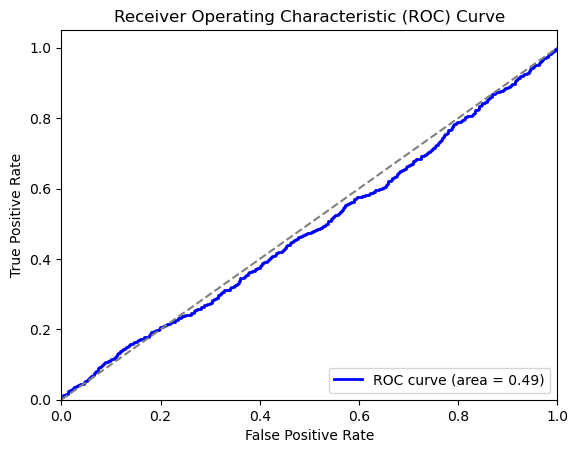

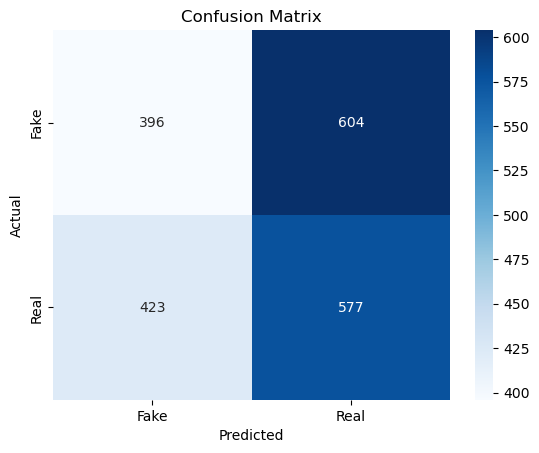

In [ ]:
import torch
import numpy as np
from torch import nn
from tqdm import tqdm  # For progress bar
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

# loss function (binary cross-entropy for binary classification)
criterion = nn.CrossEntropyLoss()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

all_preds = []
all_labels = []
all_probs = []  # hold the probabilities for the ROC curve
running_loss = 0.0

with torch.no_grad():  # No need to track gradients for evaluation
    for images, labels in tqdm(dataloader):
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)

        loss = criterion(outputs, labels)
        running_loss += loss.item()

        # Get predicted class
        _, predicted = torch.max(outputs, 1)

        # Store predictions and labels (for metrics calculation)
        all_preds.append(predicted.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

        # Store predicted probabilities for ROC curve
        probs = torch.softmax(outputs, dim=1)  
        all_probs.append(probs.cpu().numpy()[:, 1])  # Store probs for class 1 (real/fake)

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)
all_probs = np.concatenate(all_probs)

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(all_labels, all_preds).ravel()

# Additional metrics
accuracy = (tp + tn) / (tp + tn + fp + fn)
sensitivity = tp / (tp + fn) 
specificity = tn / (tn + fp)
ppv = tp / (tp + fp)  
npv = tn / (tn + fn)  

# ROC curve and AUC
fpr, tpr, thresholds = roc_curve(all_labels, all_probs) 
roc_auc = auc(fpr, tpr)

print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Sensitivity (Recall): {sensitivity:.2f}")
print(f"Specificity: {specificity:.2f}")
print(f"Positive Predictive Value (PPV): {ppv:.2f}")
print(f"Negative Predictive Value (NPV): {npv:.2f}")
print(f"Average Loss: {running_loss / len(dataloader):.4f}")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds))

# Plot ROC
import matplotlib.pyplot as plt
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# Plot confusion matrix
import seaborn as sns
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()
